# Question 5 - Data Analysis
In this notebook we aim to analyse clinical data to better understand what treatment approaches are advised at each stage of Colorectal Cancer.

We use TCGA clinical data:
https://www.cbioportal.org/study/summary?id=coadread_tcga




In [179]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

In [180]:
# Read the data
df = pd.read_csv("./data_clinical_patient.txt", sep="\t", comment="#", dtype=str)

In [181]:
# Inspect the dataframe
df.head()


,OTHER_PATIENT_ID,PATIENT_ID,FORM_COMPLETION_DATE,HISTOLOGICAL_DIAGNOSIS,PROSPECTIVE_COLLECTION,RETROSPECTIVE_COLLECTION,SEX,RACE,ETHNICITY,HISTORY_OTHER_MALIGNANCY,...,INFORMED_CONSENT_VERIFIED,INITIAL_PATHOLOGIC_DIAGNOSIS_METHOD,PROJECT_CODE,STAGE_OTHER,TISSUE_SOURCE_SITE,SITE_OF_TUMOR_TISSUE,OS_STATUS,OS_MONTHS,DFS_STATUS,DFS_MONTHS
0,f9204a59-6877-4d06-a20e-fd7ab0859ed5,TCGA-AF-2687,2/8/11,Rectal Adenocarcinoma,YES,NO,Male,WHITE,NOT HISPANIC OR LATINO,NaN,...,YES,[Not Available],[Not Available],[Not Available],AF,Rectum,0:LIVING,46.91,[Not Available],[Not Available]
1,A94E1279-A975-480A-93E9-7B1FF05CBCBF,TCGA-3L-AA1B,4/22/14,Colon Adenocarcinoma,YES,NO,Female,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,NaN,...,YES,[Not Available],[Not Available],[Not Available],3L,Colon,0:LIVING,15.61,[Not Available],[Not Available]
2,92554413-9EBC-4354-8E1B-9682F3A031D9,TCGA-4N-A93T,10/1/14,Colon Adenocarcinoma,YES,NO,Male,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,No,...,YES,[Not Available],[Not Available],[Not Available],4N,Colon,0:LIVING,4.8,0:DiseaseFree,4.8
3,A5E14ADD-1552-4606-9FFE-3A03BCF76640,TCGA-4T-AA8H,6/5/14,Colon Mucinous Adenocarcinoma,NO,YES,Female,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,No,...,YES,[Not Available],[Not Available],[Not Available],4T,Colon,0:LIVING,12.65,0:DiseaseFree,12.65
4,1136DD50-242A-4659-AAD4-C53F9E759BB3,TCGA-5M-AAT4,1/27/15,Colon Adenocarcinoma,NO,YES,Male,BLACK OR AFRICAN AMERICAN,HISPANIC OR LATINO,No,...,YES,[Not Available],[Not Available],[Not Available],5M,Colon,1:DECEASED,1.61,[Not Available],[Not Available]


In [182]:
# Inspect the dataframe
df.columns

Index(['OTHER_PATIENT_ID', 'PATIENT_ID', 'FORM_COMPLETION_DATE',
       'HISTOLOGICAL_DIAGNOSIS', 'PROSPECTIVE_COLLECTION',
       'RETROSPECTIVE_COLLECTION', 'SEX', 'RACE', 'ETHNICITY',
       'HISTORY_OTHER_MALIGNANCY', 'HISTORY_NEOADJUVANT_TRTYN',
       'INITIAL_PATHOLOGIC_DX_YEAR', 'AJCC_STAGING_EDITION',
       'AJCC_TUMOR_PATHOLOGIC_PT', 'AJCC_NODES_PATHOLOGIC_PN',
       'AJCC_METASTASIS_PATHOLOGIC_PM', 'AJCC_PATHOLOGIC_TUMOR_STAGE',
       'RESIDUAL_TUMOR', 'LYMPH_NODES_EXAMINED', 'LYMPH_NODE_EXAMINED_COUNT',
       'LYMPH_NODES_EXAMINED_HE_COUNT', 'LYMPH_NODES_EXAMINED_IHC_COUNT',
       'TUMOR_STATUS', 'VASCULAR_INVASION_INDICATOR',
       'LYMPHOVASCULAR_INVASION_INDICATOR', 'PERINEURAL_INVASION',
       'KRAS_GENE_ANALYSIS_INDICATOR', 'KRAS_MUTATION',
       'BRAF_GENE_ANALYSIS_INDICATOR', 'BRAF_GENE_ANALYSIS_RESULT', 'WEIGHT',
       'HEIGHT', 'RADIATION_TREATMENT_ADJUVANT', 'PHARMACEUTICAL_TX_ADJUVANT',
       'TREATMENT_OUTCOME_FIRST_COURSE',
       'NEW_TUMOR_EVENT_AFT

In [183]:
# Drop unnecessary columns
df = df.drop(columns=['OTHER_PATIENT_ID',
                      'FORM_COMPLETION_DATE',
                      'PROJECT_CODE',
                      'RACE',
                      'TISSUE_SOURCE_SITE',
                      'HISTOLOGICAL_DIAGNOSIS',
                      'PROSPECTIVE_COLLECTION',
                      'RETROSPECTIVE_COLLECTION',
                      'LYMPH_NODES_EXAMINED',
                      'LYMPH_NODE_EXAMINED_COUNT',
                      'LYMPH_NODES_EXAMINED_HE_COUNT',
                      'LYMPH_NODES_EXAMINED_IHC_COUNT',
                      'INITIAL_PATHOLOGIC_DX_YEAR',
                      'CLIN_M_STAGE',
                      'CLIN_N_STAGE',
                      'CLIN_T_STAGE',
                      'AJCC_STAGING_EDITION',
                      'AJCC_TUMOR_PATHOLOGIC_PT',
                      'AJCC_NODES_PATHOLOGIC_PN',
                      'AJCC_METASTASIS_PATHOLOGIC_PM',
                      'INITIAL_PATHOLOGIC_DIAGNOSIS_METHOD',
                      'INFORMED_CONSENT_VERIFIED',
                      'WEIGHT',
                      'HEIGHT',
                      'ICD_10',
                      'ICD_O_3_HISTOLOGY',
                      'ICD_O_3_SITE',
                      'STAGE_OTHER',
                      'ETHNICITY',
                      'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS',
                      'DAYS_TO_PATIENT_PROGRESSION_FREE',
                      'DAYS_TO_TUMOR_PROGRESSION',
                      'DISEASE_CODE',
                      'HISTORY_NEOADJUVANT_TRTYN',])
df.columns

Index(['PATIENT_ID', 'SEX', 'HISTORY_OTHER_MALIGNANCY',
       'AJCC_PATHOLOGIC_TUMOR_STAGE', 'RESIDUAL_TUMOR', 'TUMOR_STATUS',
       'VASCULAR_INVASION_INDICATOR', 'LYMPHOVASCULAR_INVASION_INDICATOR',
       'PERINEURAL_INVASION', 'KRAS_GENE_ANALYSIS_INDICATOR', 'KRAS_MUTATION',
       'BRAF_GENE_ANALYSIS_INDICATOR', 'BRAF_GENE_ANALYSIS_RESULT',
       'RADIATION_TREATMENT_ADJUVANT', 'PHARMACEUTICAL_TX_ADJUVANT',
       'TREATMENT_OUTCOME_FIRST_COURSE',
       'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'AGE',
       'PRIMARY_SITE_PATIENT', 'CLINICAL_STAGE', 'EXTRANODAL_INVOLVEMENT',
       'SITE_OF_TUMOR_TISSUE', 'OS_STATUS', 'OS_MONTHS', 'DFS_STATUS',
       'DFS_MONTHS'],
      dtype='object')

In [184]:
# Compressing substages into stages
df['AJCC_PATHOLOGIC_TUMOR_STAGE'] = df['AJCC_PATHOLOGIC_TUMOR_STAGE'].replace({
    'Stage IA': 'Stage I'
})
df['AJCC_PATHOLOGIC_TUMOR_STAGE'] = df['AJCC_PATHOLOGIC_TUMOR_STAGE'].replace({
    'Stage IIA': 'Stage II',
    'Stage IIB': 'Stage II',
    'Stage IIC': 'Stage II'
})
df['AJCC_PATHOLOGIC_TUMOR_STAGE'] = df['AJCC_PATHOLOGIC_TUMOR_STAGE'].replace({
    'Stage IIIA': 'Stage III',
    'Stage IIIB': 'Stage III',
    'Stage IIIC': 'Stage III'
})
df['AJCC_PATHOLOGIC_TUMOR_STAGE'] = df['AJCC_PATHOLOGIC_TUMOR_STAGE'].replace({
    'Stage IVA': 'Stage IV',
    'Stage IVB': 'Stage IV',
    'Stage IVC': 'Stage IV'
})

In [185]:
df['AJCC_PATHOLOGIC_TUMOR_STAGE'].value_counts()

,count
AJCC_PATHOLOGIC_TUMOR_STAGE,
Stage II,229
Stage III,181
Stage I,109
Stage IV,90
[Not Available],12
[Discrepancy],8


In [186]:
# Removng NA and Discrepancy values
df = df[df['AJCC_PATHOLOGIC_TUMOR_STAGE'].isin(['Stage I', 'Stage II', 'Stage III', 'Stage IV'])]

In [187]:
df['AJCC_PATHOLOGIC_TUMOR_STAGE'].value_counts()

,count
AJCC_PATHOLOGIC_TUMOR_STAGE,
Stage II,229
Stage III,181
Stage I,109
Stage IV,90


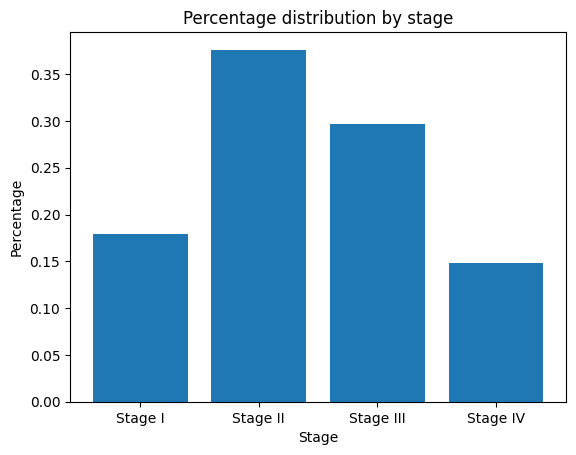

In [188]:
# Plot percentage distribution by stage for this dataset
stages = ["Stage I", "Stage II", "Stage III", "Stage IV"]
count = [109, 229, 181, 90]
p_count = [x / sum(count) for x in count]

plt.bar(stages, p_count)

plt.xlabel("Stage")
plt.ylabel("Percentage")
plt.title("Percentage distribution by stage")

plt.show()

Majority of the dataset appears to consist of stage II or stage III patients.

In [189]:
# Treatment #1: Surgery
df['RESIDUAL_TUMOR'].value_counts()


,count
RESIDUAL_TUMOR,
R0,452
[Not Available],85
R2,38
RX,28
R1,6


In [190]:
# As per the meta-data, having any of R0, R1, R2, RX in RESIDUAL_TUMOR implies that the patient underwent surgery.
# [Not Available] is marked as no surgery.

had_surgery = ["NA"] * df.shape[0]
df['HAD_SURGERY'] = had_surgery

df.loc[df['RESIDUAL_TUMOR'] != "[Not Available]", 'HAD_SURGERY'] = 'Had Surgery'
df.loc[df['RESIDUAL_TUMOR'] == "[Not Available]", 'HAD_SURGERY'] = 'No Surgery'

df['HAD_SURGERY'].value_counts()

,count
HAD_SURGERY,
Had Surgery,524
No Surgery,85


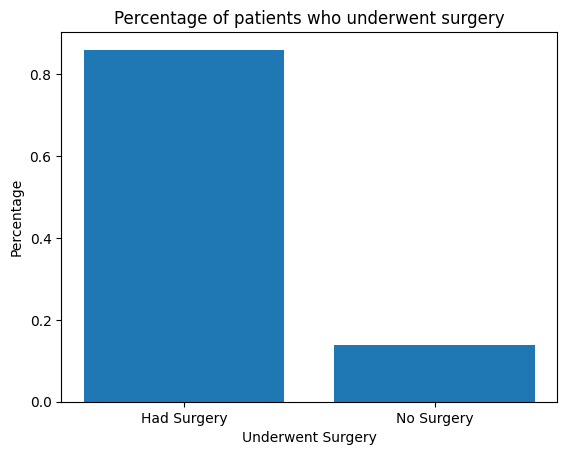

In [191]:
# Plot percentage distribution by stage for this dataset
stages = ["Had Surgery", "No Surgery"]
count = [524, 85]
p_count = [x / sum(count) for x in count]

plt.bar(stages, p_count)

plt.xlabel("Underwent Surgery")
plt.ylabel("Percentage")
plt.title("Percentage of patients who underwent surgery")

plt.show()

An overwhelming majority of patients appear to have undergone surgery.

In [192]:
# Treatment #2: Chemotherapy
df['PHARMACEUTICAL_TX_ADJUVANT'].value_counts()

,count
PHARMACEUTICAL_TX_ADJUVANT,
[Not Available],573
YES,20
NO,16


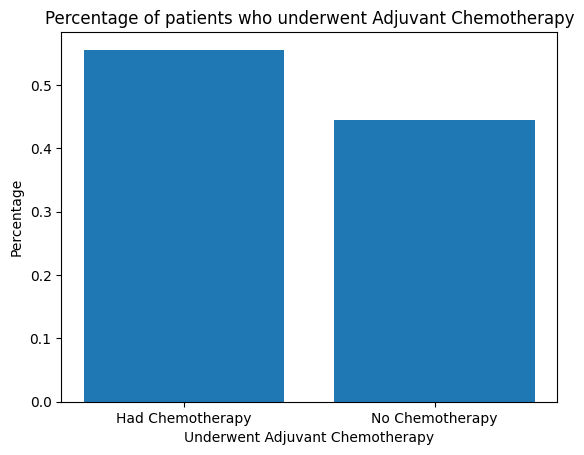

In [193]:
# We recognise the limitations of the dataset.
# Only patients with an annotation for this column were used.

# Plot percentage distribution by stage for this dataset
stages = ["Had Chemotherapy", "No Chemotherapy"]
count = [20, 16]
p_count = [x / sum(count) for x in count]

plt.bar(stages, p_count)

plt.xlabel("Underwent Adjuvant Chemotherapy")
plt.ylabel("Percentage")
plt.title("Percentage of patients who underwent Adjuvant Chemotherapy")

plt.show()

It seems to be an even split amongst the patients that have an annotation for this column.

In [194]:
# Treatment #3: Radiotherapy
df['RADIATION_TREATMENT_ADJUVANT'].value_counts()

,count
RADIATION_TREATMENT_ADJUVANT,
[Not Available],573
NO,35
YES,1


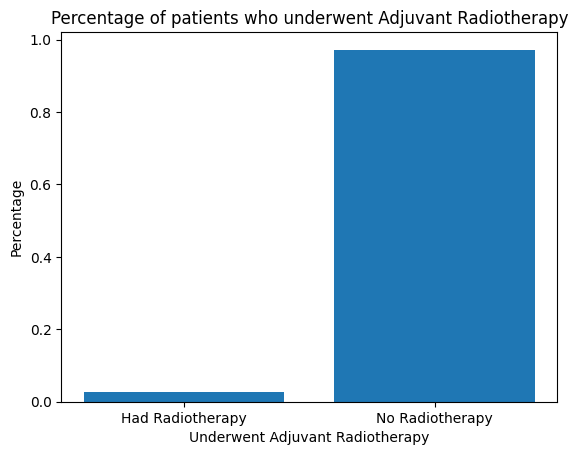

In [195]:
# We recognise the limitations of the dataset.
# Only patients with an annotation for this column were used.

# Plot percentage distribution by stage for this dataset
stages = ["Had Radiotherapy", "No Radiotherapy"]
count = [1, 35]
p_count = [x / sum(count) for x in count]

plt.bar(stages, p_count)

plt.xlabel("Underwent Adjuvant Radiotherapy")
plt.ylabel("Percentage")
plt.title("Percentage of patients who underwent Adjuvant Radiotherapy")

plt.show()

Of the patients with annotation with this category, almost all of the patients had no Adjuvant Radiotherapy.

In [196]:
df['SITE_OF_TUMOR_TISSUE'].value_counts()

,count
SITE_OF_TUMOR_TISSUE,
Colon,447
Rectum,158
[Not Available],4


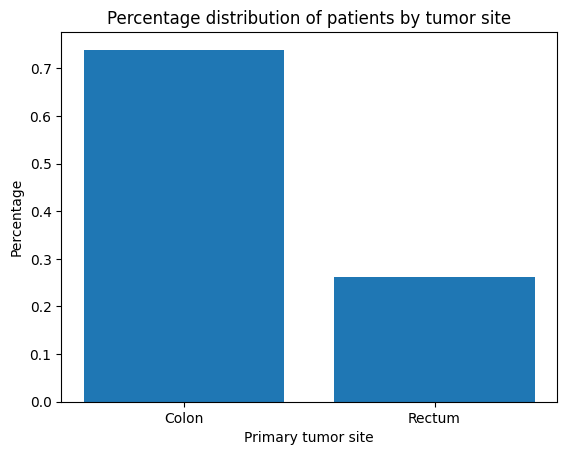

In [197]:
# We recognise the limitations of the dataset.
# Only patients with an annotation for this column were used.

# Plot percentage distribution by stage for this dataset
stages = ["Colon", "Rectum"]
count = [447, 158]
p_count = [x / sum(count) for x in count]

plt.bar(stages, p_count)

plt.xlabel("Primary tumor site")
plt.ylabel("Percentage")
plt.title("Percentage distribution of patients by tumor site")

plt.show()

Majority of the cases in this dataset had Colon as the primary tumor site. Radiotherapy is typically used for cases where Rectum was the primary tumor site, not colon.

In [199]:
# Separate the cases into four dataframes based on stage
df1 = df[df['AJCC_PATHOLOGIC_TUMOR_STAGE'] == "Stage I"]
df2 = df[df['AJCC_PATHOLOGIC_TUMOR_STAGE'] == "Stage II"]
df3 = df[df['AJCC_PATHOLOGIC_TUMOR_STAGE'] == "Stage III"]
df4 = df[df['AJCC_PATHOLOGIC_TUMOR_STAGE'] == "Stage IV"]

In [141]:
df1['HAD_SURGERY'].value_counts()

,count
HAD_SURGERY,
Had Surgery,98
No Surgery,11


In [142]:
df2['HAD_SURGERY'].value_counts()

,count
HAD_SURGERY,
Had Surgery,196
No Surgery,33


In [143]:
df3['HAD_SURGERY'].value_counts()

,count
HAD_SURGERY,
Had Surgery,156
No Surgery,25


In [144]:
df4['HAD_SURGERY'].value_counts()

,count
HAD_SURGERY,
Had Surgery,74
No Surgery,16


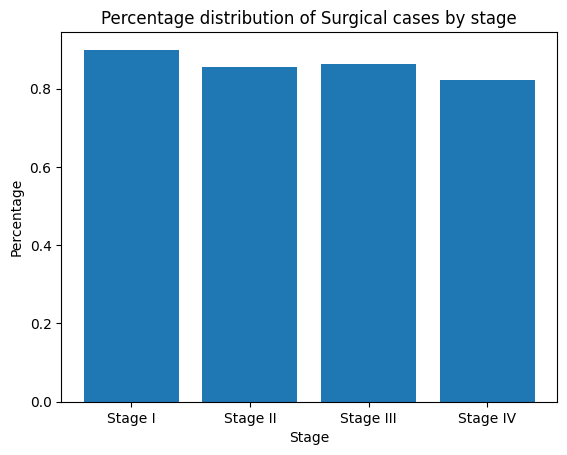

In [201]:
# Plot percentage distribution by stage for this dataset
stages = ["Stage I", "Stage II", "Stage III", "Stage IV"]
p_count = [98/(98+11), 196/(196+33), 156/(156+25), 74/(74+16)]

plt.bar(stages, p_count)

plt.xlabel("Stage")
plt.ylabel("Percentage")
plt.title("Percentage distribution of Surgical cases by stage")

plt.show()

The data clearly supports surgery as a treatment approach, but there is a clear downward trend from stage I to stage IV by about 7 %

In [145]:
df1['PHARMACEUTICAL_TX_ADJUVANT'].value_counts()

,count
PHARMACEUTICAL_TX_ADJUVANT,
[Not Available],105
NO,4


In [146]:
df2['PHARMACEUTICAL_TX_ADJUVANT'].value_counts()

,count
PHARMACEUTICAL_TX_ADJUVANT,
[Not Available],217
NO,8
YES,4


In [147]:
df3['PHARMACEUTICAL_TX_ADJUVANT'].value_counts()

,count
PHARMACEUTICAL_TX_ADJUVANT,
[Not Available],168
YES,12
NO,1


In [148]:
df4['PHARMACEUTICAL_TX_ADJUVANT'].value_counts()

,count
PHARMACEUTICAL_TX_ADJUVANT,
[Not Available],83
YES,4
NO,3


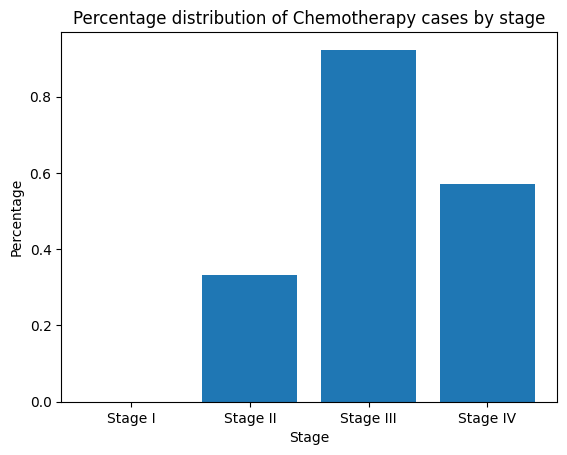

In [204]:
# Plot percentage distribution by stage for this dataset
stages = ["Stage I", "Stage II", "Stage III", "Stage IV"]
p_count = [0, 4/(4+8), 12/(12+1), 4/(4+3)]


plt.bar(stages, p_count)

plt.xlabel("Stage")
plt.ylabel("Percentage")
plt.title("Percentage distribution of Chemotherapy cases by stage")

plt.show()

We recognise the limitations of the dataset caused by NA values, but a clear trend appears. Chemo therapy is used more in the later stages.

In [149]:
df1['RADIATION_TREATMENT_ADJUVANT'].value_counts()

,count
RADIATION_TREATMENT_ADJUVANT,
[Not Available],105
NO,4


In [150]:
df2['RADIATION_TREATMENT_ADJUVANT'].value_counts()

,count
RADIATION_TREATMENT_ADJUVANT,
[Not Available],217
NO,11
YES,1


In [151]:
df3['RADIATION_TREATMENT_ADJUVANT'].value_counts()

,count
RADIATION_TREATMENT_ADJUVANT,
[Not Available],168
NO,13


In [152]:
df4['RADIATION_TREATMENT_ADJUVANT'].value_counts()

,count
RADIATION_TREATMENT_ADJUVANT,
[Not Available],83
NO,7


There is only one case involving Adjuvant Radiotherapy.

We have analysed the dataset and seen that surgery is used more in the earlier stages and Chemotherapy in the later stages.

The conclusion drawn is as follows:
If the tumor is surgically resectable and the patient is a surgical candidate, then surgery is the advised treatment.

Otherwise, Chemotherapy is the advised approach especially if the primary site of the tumor is the Colon.

Radiotherapy is an option if the primary site of the tumor is the Rectum.